In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import datetime
import itertools
import matplotlib.dates as mdates
import pandas as pd
import os

In [3]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices("GPU"))

for gpu in tf.config.list_physical_devices("GPU"):
    print(gpu)


TensorFlow: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')


In [4]:
# Data path from AGENTS.md
data_folder = "/home/haseebumer/content/data/extracted/"

# Model identifier and Google Drive output directory
model_name = "LSTM_forecast_2_15m_30m_1h_2017_2019_data"
output_folder = os.path.join(
    "model_output", model_name
)

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# File paths for extracted datasets
trainval_images_path = os.path.join(data_folder, "trainval_images_log.npy")
trainval_pv_path = os.path.join(data_folder, "trainval_pv_log.npy")
test_images_path = os.path.join(data_folder, "test_images_log.npy")
test_pv_path = os.path.join(data_folder, "test_pv_log.npy")

times_trainval_path = os.path.join(data_folder, "times_trainval.npy")
times_test_path = os.path.join(data_folder, "times_test.npy")

print("data_folder:   ", data_folder)
print("output_folder: ", output_folder)
print("trainval_pv:   ", trainval_pv_path)
print("test_pv:       ", test_pv_path)
print("times_trainval:", times_trainval_path)
print("times_test:    ", times_test_path)

data_folder:    /home/haseebumer/content/data/extracted/
output_folder:  model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data
trainval_pv:    /home/haseebumer/content/data/extracted/trainval_pv_log.npy
test_pv:        /home/haseebumer/content/data/extracted/test_pv_log.npy
times_trainval: /home/haseebumer/content/data/extracted/times_trainval.npy
times_test:     /home/haseebumer/content/data/extracted/times_test.npy


In [5]:
# Model & Forecast Horizon Parameters
# SEQ_LEN: Number of historical 1-minute time steps used as input (16 minutes)
SEQ_LEN = 16


FORECAST_HORIZONS = [15, 30, 60]
HORIZON_NAMES = ["15 min", "30 min", "1 hour"]
NUM_TARGETS = len(FORECAST_HORIZONS)

# Training hyper-parameters
NUM_FOLDS = 10  # 10-fold cross validation
NUM_EPOCHS = 200  # Max epochs (EarlyStopping will halt earlier)
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
PATIENCE = 10  # Early stopping patience

print(f"Sequence Length (History Window): {SEQ_LEN} minutes")
print(f"Target Horizons:                  {FORECAST_HORIZONS} steps ({HORIZON_NAMES})")
print(f"Number of Target Outputs:         {NUM_TARGETS}")
print(f"Cross-Validation Folds:           {NUM_FOLDS}")

Sequence Length (History Window): 16 minutes
Target Horizons:                  [15, 30, 60] steps (['15 min', '30 min', '1 hour'])
Number of Target Outputs:         3
Cross-Validation Folds:           10


In [6]:
trainval_pv = np.load(trainval_pv_path).astype(np.float32)
test_pv = np.load(test_pv_path).astype(np.float32)

times_trainval = np.load(times_trainval_path, allow_pickle=True)
times_test = np.load(times_test_path, allow_pickle=True)

print(f"trainval_pv shape: {trainval_pv.shape} | times: {times_trainval.shape}")
print(f"test_pv shape:     {test_pv.shape} | times: {times_test.shape}")

trainval_pv shape: (349372,) | times: (349372,)
test_pv shape:     (14003,) | times: (14003,)


In [7]:
def add_time_features(pv_array, times_array):
    """Combines PV values with cyclical time-of-day/year and short-term volatility features."""
    times_dt = pd.to_datetime(times_array)
    tod_frac = (times_dt.hour * 3600 + times_dt.minute * 60 + times_dt.second) / 86400.0
    doy_frac = times_dt.dayofyear / 365.25

    sin_tod = np.sin(2 * np.pi * tod_frac).astype(np.float32)
    cos_tod = np.cos(2 * np.pi * tod_frac).astype(np.float32)
    sin_doy = np.sin(2 * np.pi * doy_frac).astype(np.float32)
    cos_doy = np.cos(2 * np.pi * doy_frac).astype(np.float32)

    pv_rolling_std = pd.Series(pv_array).rolling(5, min_periods=1).std().fillna(0).values.astype(np.float32)

    return np.stack([pv_array, sin_tod, cos_tod, sin_doy, cos_doy, pv_rolling_std], axis=-1)


trainval_pv_feat = add_time_features(trainval_pv, times_trainval)
test_pv_feat = add_time_features(test_pv, times_test)

NUM_FEATURES = trainval_pv_feat.shape[-1]
print(f"trainval_pv_feat shape: {trainval_pv_feat.shape} (NUM_FEATURES={NUM_FEATURES})")

trainval_pv_feat shape: (349372, 6) (NUM_FEATURES=6)


In [8]:
def create_day_aware_forecast_sequences(
    pv_array, times_array, seq_len=16, horizons=[15, 30, 60], allow_partial=False
):
    """
    Constructs (X, y, sequence_dates, sequence_times) sequences
    ensuring that no sequence crosses overnight boundaries or
    distinct calendar dates.

    Parameters:
        pv_array: 2D numpy array of shape (T, num_features), where column 0
                  is the raw PV power generation value (kW) and any remaining
                  columns are auxiliary features (time-of-day, rolling std, etc.)
        times_array: 1D numpy array of timestamps (datetime objects)
        seq_len: Number of historical lag steps for input X
        horizons: List/tuple of forecast steps ahead [15, 60]
        allow_partial: If True, generates sequences all the way to sunset
                       (cutoff at min(horizons) instead of max(horizons)).
                       Horizons that exceed sunset are padded with NaN / None.
                       This allows 15m and 1h forecasts to run through the entire afternoon!

    Returns:
        X: Array of shape (N, seq_len, num_features)
        y: Array of shape (N, len(horizons)) [or (N,) if single horizon] — always raw PV (column 0)
        valid_dates: Array of base calendar dates (N,)
        valid_times: Array of target forecast timestamps (N, len(horizons))
    """
    is_multi = isinstance(horizons, (list, tuple, np.ndarray))
    if is_multi:
        horizon_list = list(horizons)
        max_horizon = max(horizon_list)
        min_horizon = min(horizon_list)
    else:
        horizon_list = [horizons]
        max_horizon = horizons
        min_horizon = horizons

    cutoff_horizon = min_horizon if allow_partial else max_horizon

    dates = np.array(
        [
            (
                t.date()
                if isinstance(t, (datetime.datetime, datetime.date))
                else pd.to_datetime(t).date()
            )
            for t in times_array
        ]
    )

    unique_dates = np.unique(dates)

    X_list, y_list = [], []
    valid_dates_list = []
    valid_times_list = []

    for d in unique_dates:
        day_indices = np.where(dates == d)[0]
        num_day_points = len(day_indices)

        # Skip days that do not have enough points for sequence + cutoff horizon
        if num_day_points <= seq_len + cutoff_horizon:
            continue

        day_pv = pv_array[day_indices]
        day_times = times_array[day_indices]

        for i in range(seq_len, num_day_points - cutoff_horizon):
            seq_x = day_pv[i - seq_len : i]  # Shape: (seq_len, num_features)

            if is_multi:
                seq_y = []
                target_times = []
                for h in horizon_list:
                    if i + h < num_day_points:
                        seq_y.append(day_pv[i + h, 0])  # target = raw PV column only
                        target_times.append(day_times[i + h])
                    else:
                        seq_y.append(np.nan)
                        target_times.append(None)
            else:
                seq_y = day_pv[i + horizon_list[0], 0]  # target = raw PV column only
                target_times = day_times[i + horizon_list[0]]

            X_list.append(seq_x)
            y_list.append(seq_y)
            valid_dates_list.append(d)
            valid_times_list.append(target_times)

    X = np.array(X_list, dtype=np.float32)  # Shape: (N, seq_len, num_features)

    y = np.array(y_list, dtype=np.float32)  # Shape: (N, num_horizons) or (N,)

    valid_dates = np.array(valid_dates_list)
    valid_times = np.array(valid_times_list, dtype=object)

    return X, y, valid_dates, valid_times


X_trainval, y_trainval, dates_trainval_seq, times_trainval_seq = (
    create_day_aware_forecast_sequences(
        trainval_pv_feat, times_trainval, seq_len=SEQ_LEN, horizons=FORECAST_HORIZONS
    )
)

# Set allow_partial=True for test set so 15m and 1h forecasts continue all the way to sunset!
X_test, y_test, dates_test_seq, times_test_seq = create_day_aware_forecast_sequences(
    test_pv_feat, times_test, seq_len=SEQ_LEN, horizons=FORECAST_HORIZONS, allow_partial=True
)

print(f"X_trainval shape: {X_trainval.shape}, y_trainval shape: {y_trainval.shape}")
print(f"X_test shape:     {X_test.shape}, y_test shape:     {y_test.shape}")
print(
    f"dates_trainval:   {dates_trainval_seq.shape}, times_trainval: {times_trainval_seq.shape}"
)
print(
    f"dates_test:       {dates_test_seq.shape}, times_test:       {times_test_seq.shape}"
)

X_trainval shape: (311600, 16, 6), y_trainval shape: (311600, 3)
X_test shape:     (13383, 16, 6), y_test shape:     (13383, 3)
dates_trainval:   (311600,), times_trainval: (311600, 3)
dates_test:       (13383,), times_test:       (13383, 3)


In [9]:
def day_block_shuffle_indices(dates_array, seed=1):
    """
    Returns the unique calendar dates in a shuffled order.
    (Renamed conceptually to "shuffled dates" — actual index
    assignment now happens per-fold in cv_split_indices.)
    """
    unique_dates = np.unique(dates_array)

    rng = np.random.RandomState(seed)
    shuffled_dates = unique_dates.copy()
    rng.shuffle(shuffled_dates)

    return shuffled_dates


def cv_split_indices(shuffled_dates, dates_array, fold_index, num_folds=10):
    """
    Splits shuffled *dates* into num_folds contiguous date-blocks.
    fold_index's block becomes validation; every sample belonging
    to a date in that block goes to validation, regardless of how
    many sequences that day contributed — no day is ever split
    across train/val.
    """
    # Partition the (already shuffled) dates into num_folds groups
    date_folds = np.array_split(shuffled_dates, num_folds)
    val_dates = set(date_folds[fold_index])

    # Assign every SAMPLE (not date) to train or val based on its date
    val_mask = np.array([d in val_dates for d in dates_array])

    all_idx = np.arange(len(dates_array))
    val_idx = all_idx[val_mask]
    train_idx = all_idx[~val_mask]

    # Local shuffle (same as before)
    rng = np.random.RandomState(fold_index)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def build_tf_dataset(X, y, indices, batch_size=256, is_training=True):
    """
    Builds an optimized tf.data.Dataset pipeline.
    """
    X_sub = X[indices]
    y_sub = y[indices]

    ds = tf.data.Dataset.from_tensor_slices((X_sub, y_sub))

    if is_training:
        ds = ds.shuffle(buffer_size=min(len(indices), 10000), seed=42)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds

In [10]:
def build_lstm_forecast_model(
    seq_len=16,
    num_features=6,
    num_outputs=3,
    lstm_units=(96, 96),
    dense_units=128,
):
    inputs = keras.Input(shape=(seq_len, num_features), name="pv_sequence_input")

    x = keras.layers.Conv1D(32, kernel_size=3, padding="causal", activation="relu", name="conv1d_front")(inputs)
    x = keras.layers.LSTM(lstm_units[0], return_sequences=True, name="lstm_1")(x)
    x = keras.layers.LSTM(lstm_units[1], return_sequences=False, name="lstm_2")(x)
    shared = keras.layers.Dense(dense_units, activation="relu", name="dense_shared")(x)

    outputs = []
    for i in range(num_outputs):
        h = keras.layers.Dense(64, activation="relu", name=f"head_{i}_dense")(shared)
        out = keras.layers.Dense(1, activation="linear", name=f"horizon_{i}_out")(h)
        outputs.append(out)

    final_output = keras.layers.Concatenate(name="pv_forecast")(outputs)

    model = keras.Model(
        inputs=inputs,
        outputs=final_output,
        name=f"LSTM_Solar_Forecaster_{num_outputs}Horizons_MultiHead",
    )

    return model


sample_model = build_lstm_forecast_model(
    seq_len=SEQ_LEN, num_features=NUM_FEATURES, num_outputs=NUM_TARGETS
)

sample_model.summary()

I0000 00:00:1788945625.824234   23228 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8103 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:23:00.0, compute capability: 8.6
I0000 00:00:1788945625.825865   23228 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 8013 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:2d:00.0, compute capability: 8.6


Model: "LSTM_Solar_Forecaster_3Horizons_MultiHead"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pv_sequence_input   │ (None, 16, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_front        │ (None, 16, 32)    │        608 │ pv_sequence_inpu… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 16, 96)    │     49,536 │ conv1d_front[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 96)        │     74,112 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared        │ (None, 128)       │     12,416 │ lstm_2[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_0_dense        │ (None, 64)        │      8,256 │ dense_shared[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_1_dense        │ (None, 64)        │      8,256 │ dense_shared[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_2_dense        │ (None, 64)        │      8,256 │ dense_shared[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_0_out       │ (None, 1)         │         65 │ head_0_dense[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_1_out       │ (None, 1)         │         65 │ head_1_dense[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_2_out       │ (None, 1)         │         65 │ head_2_dense[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pv_forecast         │ (None, 3)         │          0 │ horizon_0_out[0]… │
│ (Concatenate)       │                   │            │ horizon_1_out[0]… │
│                     │                   │            │ horizon_2_out[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 161,635 (631.39 KB)

 Trainable params: 161,635 (631.39 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
shuffled_dates = day_block_shuffle_indices(dates_trainval_seq, seed=1)

# --- Resume support: load existing history if this cell was run before ---
history_paths = {
    "train_loss": os.path.join(output_folder, "train_loss_hist.npy"),
    "val_loss": os.path.join(output_folder, "val_loss_hist.npy"),
    "train_mae": os.path.join(output_folder, "train_mae_hist.npy"),
    "val_mae": os.path.join(output_folder, "val_mae_hist.npy"),
}

if all(os.path.exists(p) for p in history_paths.values()):
    train_loss_hist = list(np.load(history_paths["train_loss"], allow_pickle=True))
    val_loss_hist = list(np.load(history_paths["val_loss"], allow_pickle=True))
    train_mae_hist = list(np.load(history_paths["train_mae"], allow_pickle=True))
    val_mae_hist = list(np.load(history_paths["val_mae"], allow_pickle=True))
    print(
        f"Resuming: found existing history for {len(train_loss_hist)} completed fold(s)."
    )
else:
    train_loss_hist = []
    val_loss_hist = []
    train_mae_hist = []
    val_mae_hist = []

# A fold counts as "done" only if its history was already recorded above
# (a checkpoint file alone isn't proof the fold finished/saved).
start_fold = len(train_loss_hist)

if start_fold >= NUM_FOLDS:
    print(f"All {NUM_FOLDS} folds already completed. Nothing to train.")

for fold in range(start_fold, NUM_FOLDS):
    print(f"\n{'='*25} FOLD {fold + 1} / {NUM_FOLDS} {'='*25}")

    train_idx, val_idx = cv_split_indices(
        shuffled_dates, dates_trainval_seq, fold_index=fold, num_folds=NUM_FOLDS
    )

    # Datasets
    ds_train = build_tf_dataset(
        X_trainval, y_trainval, train_idx, batch_size=BATCH_SIZE, is_training=True
    )

    ds_val = build_tf_dataset(
        X_trainval, y_trainval, val_idx, batch_size=BATCH_SIZE, is_training=False
    )

    # Model definition
    keras.backend.clear_session()

    model = build_lstm_forecast_model(
        seq_len=SEQ_LEN,
        num_features=NUM_FEATURES,
        num_outputs=NUM_TARGETS,
        lstm_units=(96, 96),
        dense_units=128,
    )

    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

    # Callbacks
    checkpoint_dir = os.path.join(output_folder, f"repetition_{fold + 1}")
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(
        checkpoint_dir, f"best_model_repetition_{fold + 1}.h5"
    )

    earlystop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        mode="min",
        verbose=1,
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor="val_loss", mode="min", save_best_only=True, verbose=1
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    # Training
    history = model.fit(
        ds_train,
        epochs=NUM_EPOCHS,
        validation_data=ds_val,
        callbacks=[earlystop, checkpoint, reduce_lr],
        verbose=1,
    )

    # Store training history
    train_loss_hist.append(history.history["loss"])
    val_loss_hist.append(history.history["val_loss"])
    train_mae_hist.append(history.history["mae"])
    val_mae_hist.append(history.history["val_mae"])

    # Save history arrays (checkpointed after EVERY fold, so a crash mid-run
    # only loses the in-progress fold, not previously completed ones)
    np.save(
        os.path.join(output_folder, "train_loss_hist.npy"),
        np.array(train_loss_hist, dtype=object),
    )
    np.save(
        os.path.join(output_folder, "val_loss_hist.npy"),
        np.array(val_loss_hist, dtype=object),
    )
    np.save(
        os.path.join(output_folder, "train_mae_hist.npy"),
        np.array(train_mae_hist, dtype=object),
    )
    np.save(
        os.path.join(output_folder, "val_mae_hist.npy"),
        np.array(val_mae_hist, dtype=object),
    )

    print(f"Fold {fold + 1} complete and saved.")


========================= FOLD 1 / 10 =========================
Epoch 1/200


/home/haseebumer/skippd-solar-forecasting/aienv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788945630.388649   24053 cuda_dnn.cc:461] Loaded cuDNN version 92400


1102/1102 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.4015 - mae: 1.4566
Epoch 1: val_loss improved from None to 7.70085, saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5



Epoch 1: finished saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 8.4015 - mae: 1.4566 - val_loss: 7.7009 - val_mae: 1.4740 - learning_rate: 0.0010
Epoch 2/200
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.2493 - mae: 1.1815
Epoch 2: val_loss improved from 7.70085 to 7.37494, saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5



Epoch 2: finished saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 5.2493 - mae: 1.1815 - val_loss: 7.3749 - val_mae: 1.5012 - learning_rate: 0.0010
Epoch 3/200
1099/1102 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0754 - mae: 1.1462
Epoch 3: val_loss did not improve from 7.37494
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 5.0767 - mae: 1.1462 - val_loss: 7.4220 - val_mae: 1.4122 - learning_rate: 0.0010
Epoch 4/200
1098/1102 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.9454 - mae: 1.1272
Epoch 4: val_loss did not improve from 7.37494
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 4.9454 - mae: 1.1272 - val_loss: 7.6284 - val_mae: 1.4725 - learning_rate: 0.0010
Epoch 5/200
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8185 - mae: 1.1015
Epoch 5: val_loss did not improve from 7.37494

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1

...


Epoch 4: finished saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_9/best_model_repetition_9.h5
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 5.2066 - mae: 1.1638 - val_loss: 4.7287 - val_mae: 1.0252 - learning_rate: 0.0010
Epoch 5/200
1092/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0812 - mae: 1.1348
Epoch 5: val_loss did not improve from 4.72871
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 5.0812 - mae: 1.1348 - val_loss: 4.8075 - val_mae: 1.0236 - learning_rate: 0.0010
Epoch 6/200
1090/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.9472 - mae: 1.1094
Epoch 6: val_loss did not improve from 4.72871
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 4.9449 - mae: 1.1090 - val_loss: 4.7453 - val_mae: 0.9838 - learning_rate: 0.0010
Epoch 7/200
1093/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8228 - mae: 1.0938
Epoch 7: val_loss did not improve from 4.72871

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1


Epoch 1: finished saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 9.3607 - mae: 1.5441 - val_loss: 4.4938 - val_mae: 1.0792 - learning_rate: 0.0010
Epoch 2/200
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5310 - mae: 1.2143
Epoch 2: val_loss improved from 4.49383 to 4.42313, saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5



Epoch 2: finished saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 5.5305 - mae: 1.2142 - val_loss: 4.4231 - val_mae: 1.1852 - learning_rate: 0.0010
Epoch 3/200
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.3697 - mae: 1.1827
Epoch 3: val_loss improved from 4.42313 to 4.30140, saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5



Epoch 3: finished saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 5.3696 - mae: 1.1827 - val_loss: 4.3014 - val_mae: 1.0026 - learning_rate: 0.0010
Epoch 4/200
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.2148 - mae: 1.1538
Epoch 4: val_loss improved from 4.30140 to 4.27619, saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5



Epoch 4: finished saving model to model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 5.2154 - mae: 1.1539 - val_loss: 4.2762 - val_mae: 0.9269 - learning_rate: 0.0010
Epoch 5/200
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.1004 - mae: 1.1456
Epoch 5: val_loss did not improve from 4.27619
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 5.1004 - mae: 1.1456 - val_loss: 4.2832 - val_mae: 0.9183 - learning_rate: 0.0010
Epoch 6/200
1086/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.9743 - mae: 1.1240
Epoch 6: val_loss did not improve from 4.27619
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 4.9732 - mae: 1.1236 - val_loss: 4.4447 - val_mae: 0.9500 - learning_rate: 0.0010
Epoch 7/200
1089/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8400 - mae: 1.1050
Epoch 7: val_loss did not improve from 4.27619

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

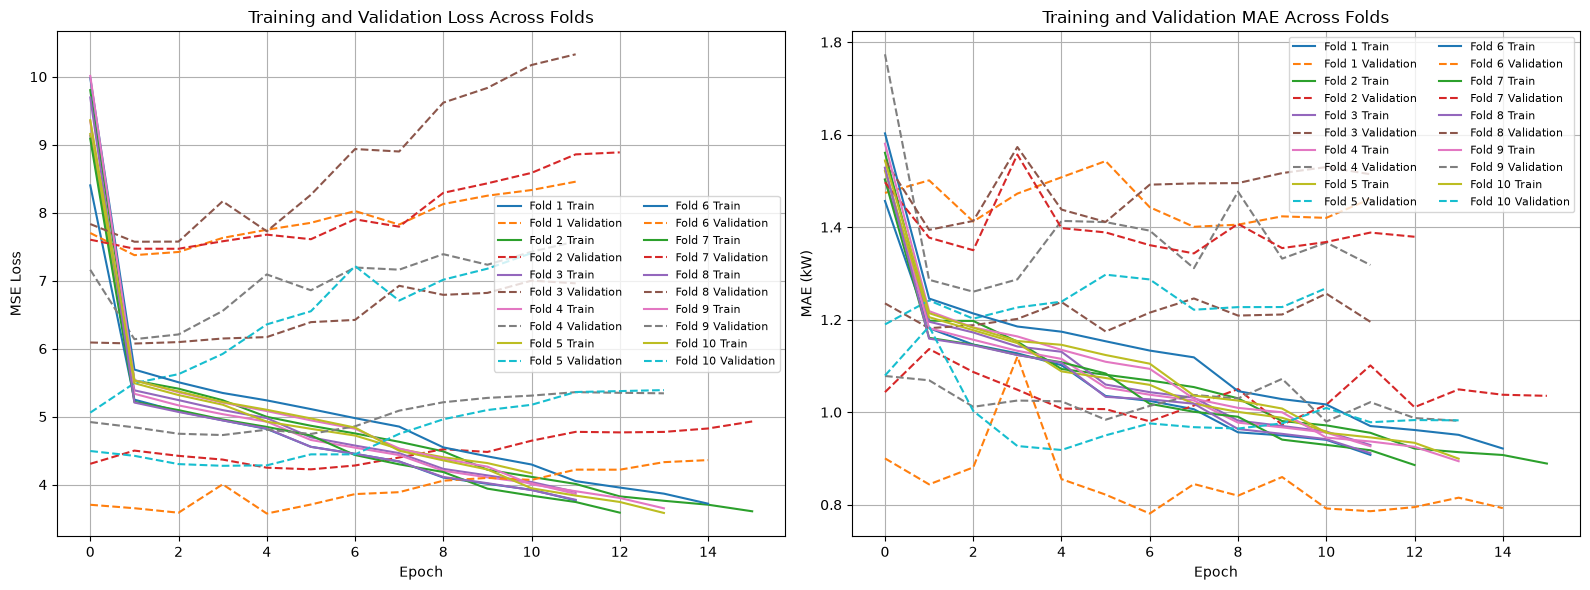

In [12]:
fig, axarr = plt.subplots(1, 2, figsize=(16, 6))

# TRAINING & VALIDATION LOSS
for fold in range(NUM_FOLDS):
    axarr[0].plot(train_loss_hist[fold], label=f"Fold {fold + 1} Train")
    axarr[0].plot(
        val_loss_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[0].set_xlabel("Epoch")
axarr[0].set_ylabel("MSE Loss")
axarr[0].set_title("Training and Validation Loss Across Folds")
axarr[0].legend(ncol=2, fontsize=8)
axarr[0].grid(True)

# TRAINING & VALIDATION MAE
for fold in range(NUM_FOLDS):
    axarr[1].plot(train_mae_hist[fold], label=f"Fold {fold + 1} Train")
    axarr[1].plot(
        val_mae_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[1].set_xlabel("Epoch")
axarr[1].set_ylabel("MAE (kW)")
axarr[1].set_title("Training and Validation MAE Across Folds")
axarr[1].legend(ncol=2, fontsize=8)
axarr[1].grid(True)

plt.tight_layout()
plt.show()

In [13]:
best_train_loss_mse = np.zeros(NUM_FOLDS)
best_val_loss_mse = np.zeros(NUM_FOLDS)

print(f"{'Fold':<8} | {'Best Train RMSE (kW)':<22} | {'Best Val RMSE (kW)':<20}")
print("-" * 56)

for i in range(NUM_FOLDS):
    best_val_loss_mse[i] = np.min(val_loss_hist[i])
    idx = np.argmin(val_loss_hist[i])
    best_train_loss_mse[i] = train_loss_hist[i][idx]

    train_rmse = np.sqrt(best_train_loss_mse[i])
    val_rmse = np.sqrt(best_val_loss_mse[i])
    print(f"Fold {i + 1:02d}  | {train_rmse:<22.3f} | {val_rmse:<20.3f}")

print("-" * 56)
print(f"Mean Train RMSE:      {np.mean(np.sqrt(best_train_loss_mse)):.3f} kW")
print(f"Mean Validation RMSE: {np.mean(np.sqrt(best_val_loss_mse)):.3f} kW")

Fold     | Best Train RMSE (kW)   | Best Val RMSE (kW)  
--------------------------------------------------------
Fold 01  | 2.291                  | 2.716               
Fold 02  | 2.206                  | 2.055               
Fold 03  | 2.321                  | 2.465               
Fold 04  | 2.310                  | 2.478               
Fold 05  | 3.026                  | 2.249               
Fold 06  | 2.289                  | 1.891               
Fold 07  | 2.257                  | 2.733               
Fold 08  | 2.282                  | 2.752               
Fold 09  | 2.282                  | 2.175               
Fold 10  | 2.284                  | 2.068               
--------------------------------------------------------
Mean Train RMSE:      2.355 kW
Mean Validation RMSE: 2.358 kW


In [14]:
predictions = np.zeros((NUM_FOLDS, len(X_test), NUM_TARGETS), dtype=np.float32)

for fold in range(NUM_FOLDS):
    checkpoint_path = os.path.join(
        output_folder, f"repetition_{fold + 1}", f"best_model_repetition_{fold + 1}.h5"
    )

    print(f"Loading fold {fold + 1} model from: {checkpoint_path}")
    fold_model = keras.models.load_model(checkpoint_path, compile=False)

    pred = fold_model.predict(X_test, batch_size=512, verbose=0)
    if pred.ndim == 1 or (pred.ndim == 2 and pred.shape[1] == 1 and NUM_TARGETS == 1):
        pred = np.reshape(pred, (-1, 1))

    predictions[fold] = pred

# Save individual fold predictions
np.save(os.path.join(output_folder, "test_predictions_all_folds.npy"), predictions)

# Ensemble average across folds
ensemble_predictions = np.mean(predictions, axis=0)

np.save(
    os.path.join(output_folder, "test_predictions_ensemble.npy"), ensemble_predictions
)
print(f"\nEnsemble predictions saved. Shape: {ensemble_predictions.shape}")

Loading fold 1 model from: model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5
Loading fold 2 model from: model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_2/best_model_repetition_2.h5
Loading fold 3 model from: model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_3/best_model_repetition_3.h5
Loading fold 4 model from: model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_4/best_model_repetition_4.h5
Loading fold 5 model from: model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_5/best_model_repetition_5.h5
Loading fold 6 model from: model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_6/best_model_repetition_6.h5
Loading fold 7 model from: model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_7/best_model_repetition_7.h5
Loading fold 8 model from: model_output/LSTM_forecast_2_15m_30m_1h_2017_2019_data/repetition_8/best_model_repetition_8.h5
Loading fold 9 model fro

COMPLETE TEST SET FORECAST RESULTS (13,383 Sequences)
Horizon      | Lead Steps   | Test RMSE (kW)   | Test MAE (kW) 
--------------------------------------------------------------------
15 min       | 15           | 3.099            | 1.616         
30 min       | 30           | 3.387            | 1.840         
1 hour       | 60           | 3.638            | 2.106         
--------------------------------------------------------------------
OVERALL      | All          | 3.376            | 1.848         


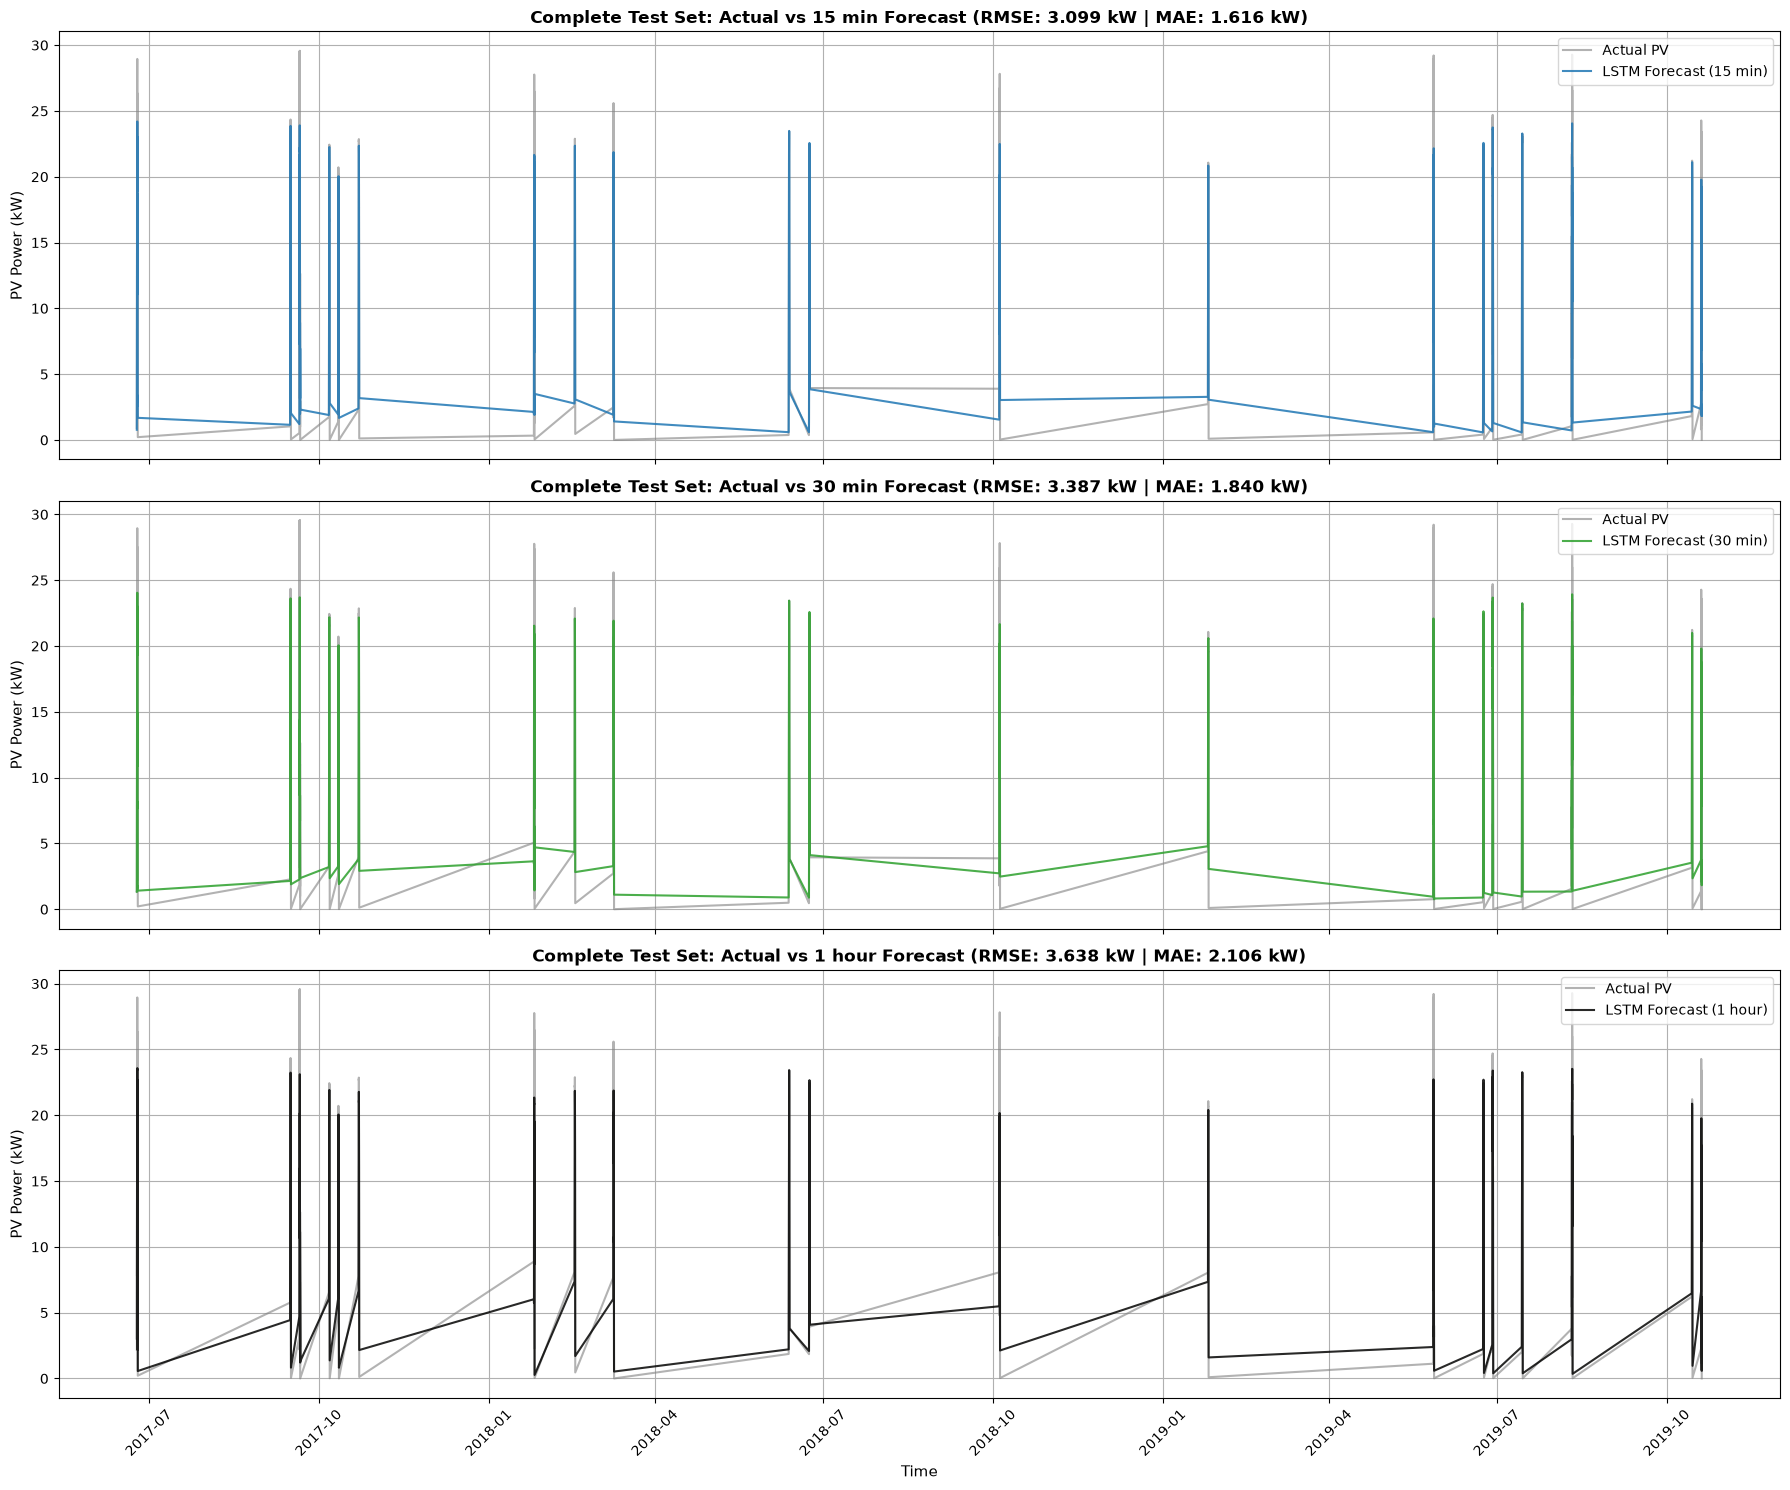

In [15]:
# TEST SET EVALUATION ACROSS ALL HORIZONS
errors = ensemble_predictions - y_test  # Shape: (N, NUM_TARGETS)

print("=" * 68)
print(f"COMPLETE TEST SET FORECAST RESULTS ({len(y_test):,} Sequences)")
print("=" * 68)
print(
    f"{'Horizon':<12} | {'Lead Steps':<12} | {'Test RMSE (kW)':<16} | {'Test MAE (kW)':<14}"
)
print("-" * 68)

horizon_metrics = {}
for k, (h_name, h_steps) in enumerate(zip(HORIZON_NAMES, FORECAST_HORIZONS)):
    h_err = errors[:, k] if errors.ndim > 1 else errors
    valid = ~np.isnan(h_err)
    h_rmse = np.sqrt(np.mean(np.square(h_err[valid])))
    h_mae = np.mean(np.abs(h_err[valid]))
    horizon_metrics[h_name] = {"rmse": h_rmse, "mae": h_mae}
    print(f"{h_name:<12} | {h_steps:<12} | {h_rmse:<16.3f} | {h_mae:<14.3f}")

print("-" * 68)
valid_all = ~np.isnan(errors)
rmse_overall = np.sqrt(np.mean(np.square(errors[valid_all])))
mae_overall = np.mean(np.abs(errors[valid_all]))
print(f"{'OVERALL':<12} | {'All':<12} | {rmse_overall:<16.3f} | {mae_overall:<14.3f}")
print("=" * 68)

# TIME-SERIES PLOTS FOR COMPLETE TEST SET
fig, axes = plt.subplots(NUM_TARGETS, 1, figsize=(18, 5 * NUM_TARGETS), sharex=True)
if NUM_TARGETS == 1:
    axes = [axes]

colors = ["#1f77b4", "#2ca02c", "#030302"]  # Blue (15m), Green (30m), Orange (1h)

for k, (h_name, h_color) in enumerate(zip(HORIZON_NAMES, colors)):
    ax = axes[k]
    h_times = times_test_seq[:, k] if times_test_seq.ndim > 1 else times_test_seq
    h_y_true = y_test[:, k] if y_test.ndim > 1 else y_test
    h_y_pred = (
        ensemble_predictions[:, k]
        if ensemble_predictions.ndim > 1
        else ensemble_predictions
    )
    valid_k = np.array(
        [t is not None and not np.isnan(y) for t, y in zip(h_times, h_y_true)]
    )

    ax.plot(
        h_times[valid_k],
        h_y_true[valid_k],
        color="#808080",
        alpha=0.6,
        label="Actual PV",
    )
    ax.plot(
        h_times[valid_k],
        h_y_pred[valid_k],
        color=h_color,
        alpha=0.85,
        label=f"LSTM Forecast ({h_name})",
    )
    ax.set_ylabel("PV Power (kW)", fontsize=11)
    ax.set_title(
        f"Complete Test Set: Actual vs {h_name} Forecast "
        f"(RMSE: {horizon_metrics[h_name]['rmse']:.3f} kW | MAE: {horizon_metrics[h_name]['mae']:.3f} kW)",
        fontsize=12,
        fontweight="bold",
    )
    ax.legend(loc="upper right")
    ax.grid(True)

axes[-1].set_xlabel("Time", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# SUNNY AND CLOUDY DATES FROM THE SKIPP'D PAPER
sunny_dates = [
    (2017, 9, 15),
    (2017, 10, 6),
    (2017, 10, 22),
    (2018, 2, 16),
    (2018, 6, 12),
    (2018, 6, 23),
    (2019, 1, 25),
    (2019, 6, 23),
    (2019, 7, 14),
    (2019, 10, 14),
]

cloudy_dates = [
    (2017, 6, 24),
    (2017, 9, 20),
    (2017, 10, 11),
    (2018, 1, 25),
    (2018, 3, 9),
    (2018, 10, 4),
    (2019, 5, 27),
    (2019, 6, 28),
    (2019, 8, 10),
    (2019, 10, 19),
]

sunny_dates_test = [datetime.date(y, m, d) for y, m, d in sunny_dates]
cloudy_dates_test = [datetime.date(y, m, d) for y, m, d in cloudy_dates]

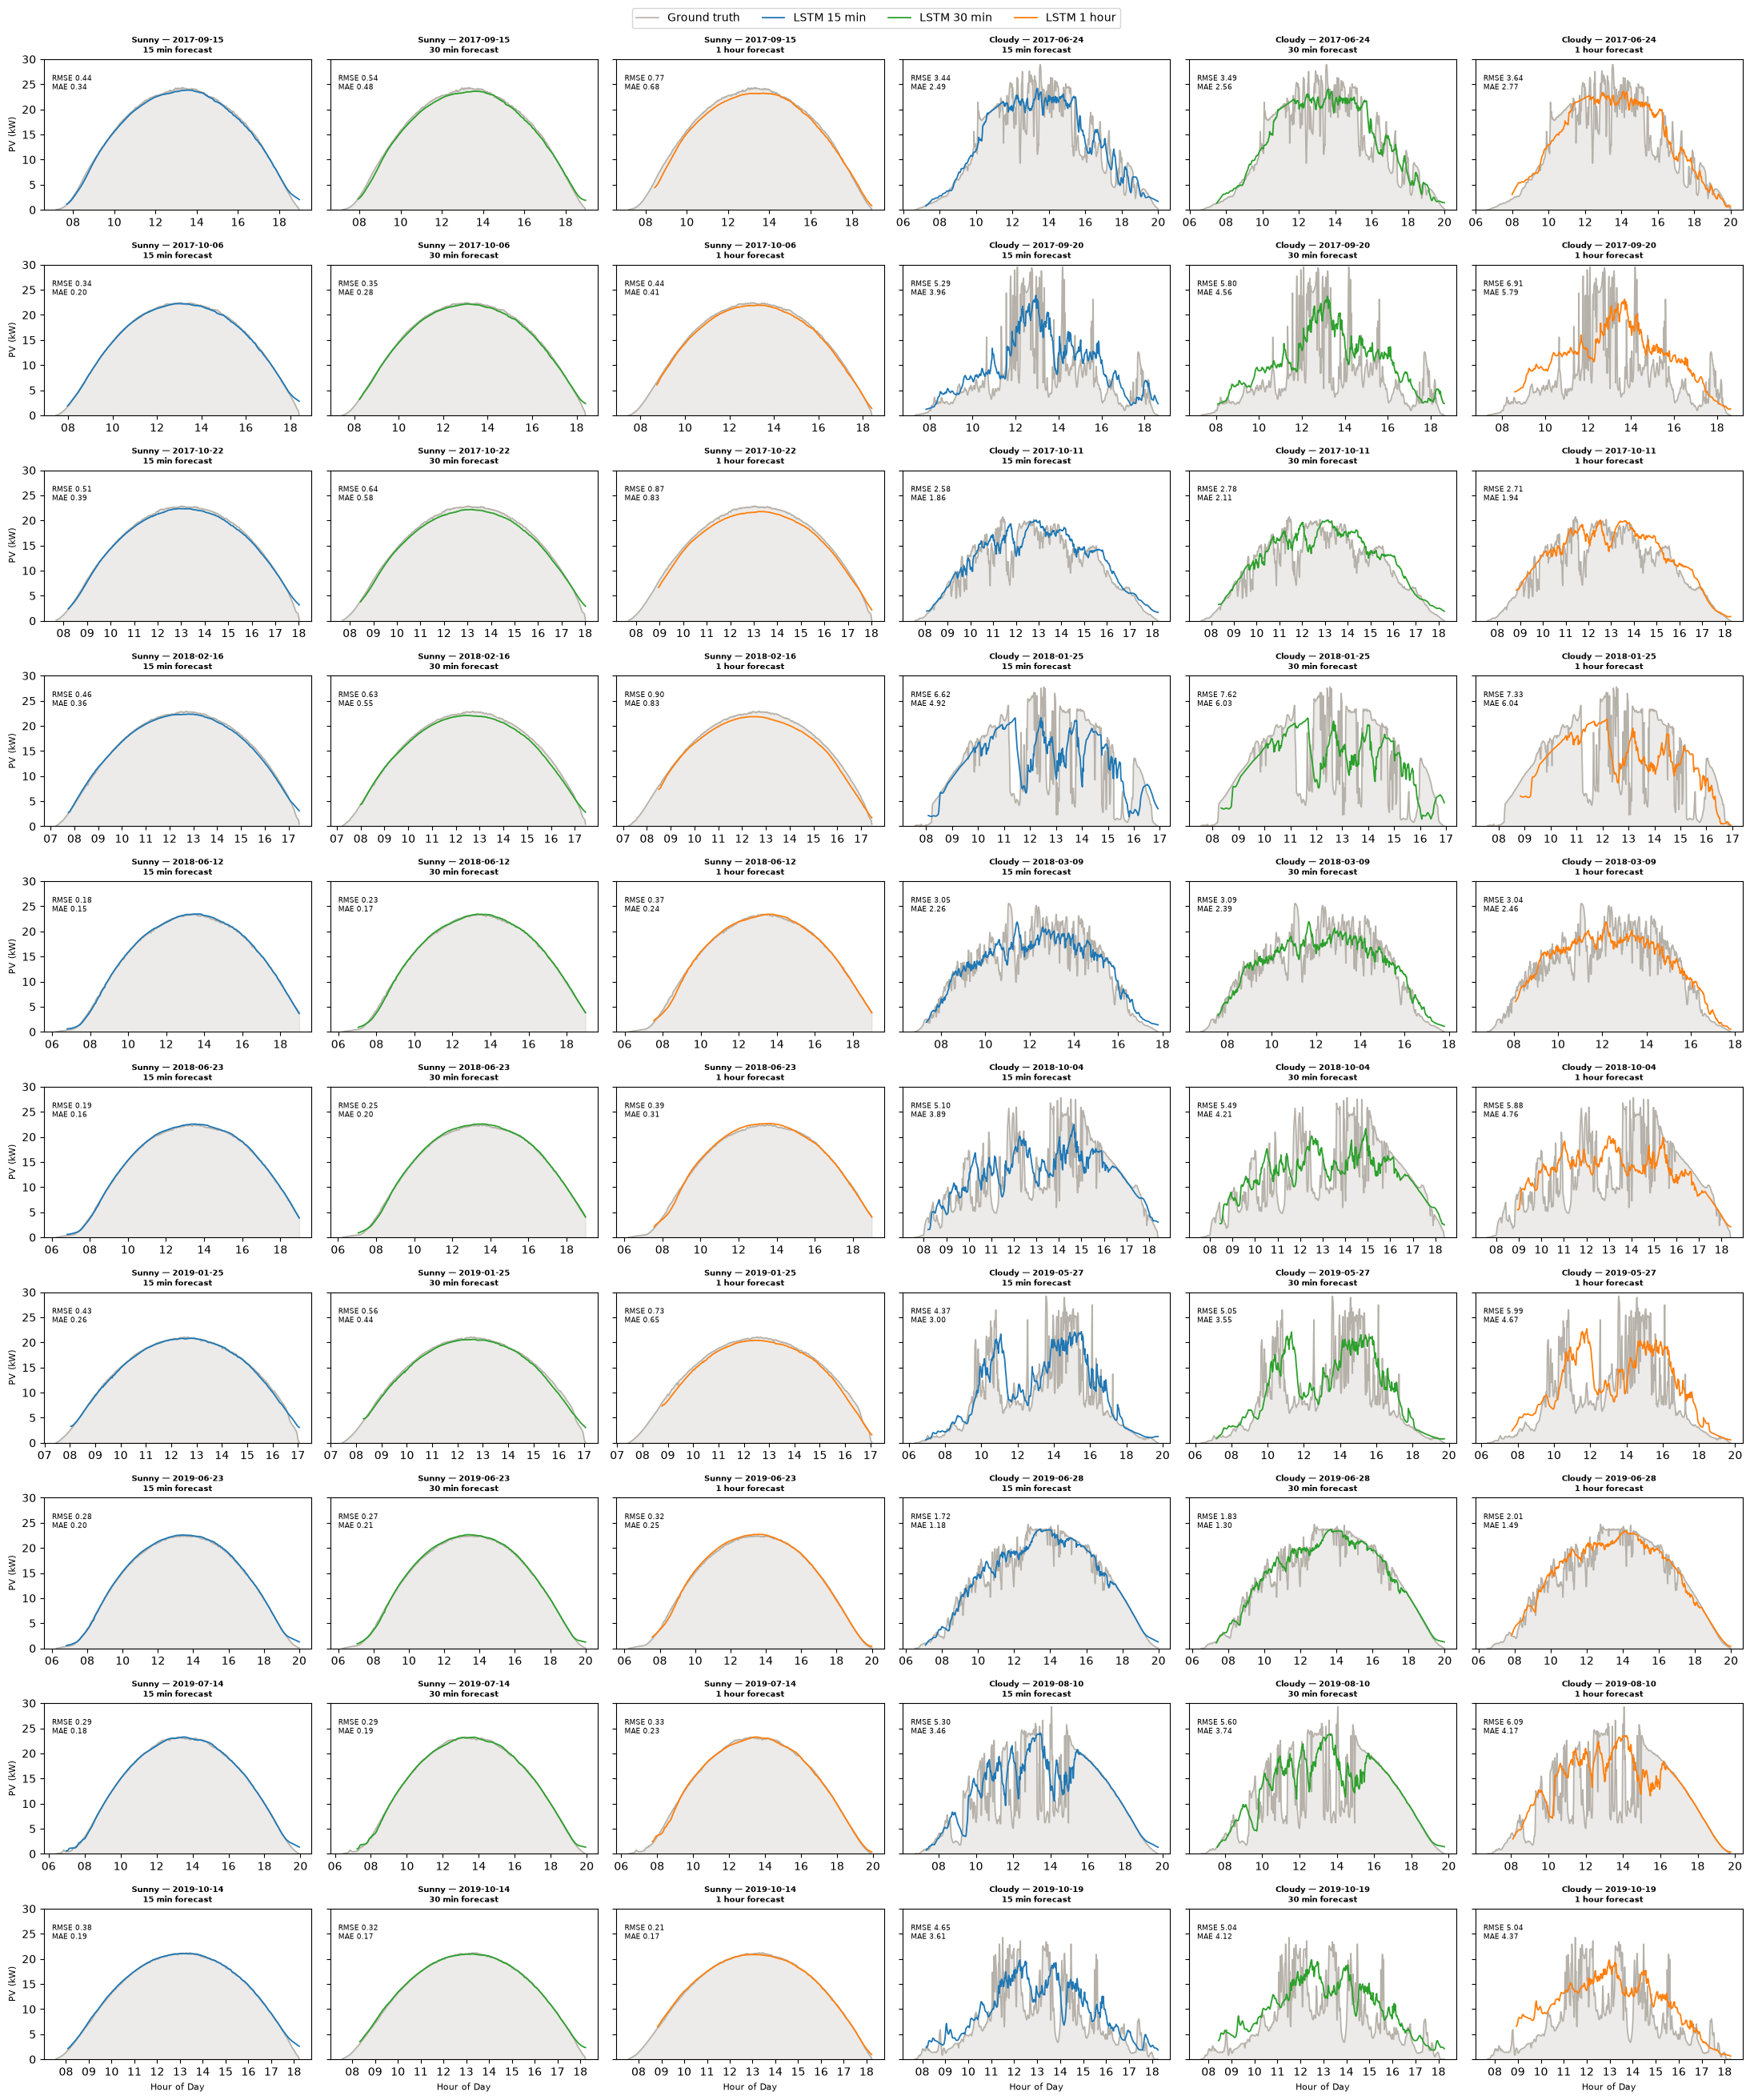

In [18]:
import math

# Precompute full-day test dates to plot complete diurnal ground truth
dates_test_all = np.array(
    [
        (
            t.date()
            if isinstance(t, (datetime.datetime, datetime.date))
            else pd.to_datetime(t).date()
        )
        for t in times_test
    ]
)

xfmt = mdates.DateFormatter("%H")
fmt_date = datetime.date(2000, 1, 1)

COLOR_GT = "#B6B1A9"
HORIZON_COLORS = [
    "#1f77b4",
    "#2ca02c",
    "#ff7f0e",
]  # Blue (15m), Green (30m), Orange (1h)


def plot_single_horizon(ax, target_date, day_type_label, horizon_idx, show_legend=False):
    """Plot full-day ground truth + a SINGLE horizon's forecast on one axis."""
    date_mask = dates_test_seq == target_date
    if not np.any(date_mask):
        ax.text(0.5, 0.5, f"Date {target_date}\nnot in test set", ha="center", fontsize=7)
        return

    h_name = HORIZON_NAMES[horizon_idx]
    h_color = HORIZON_COLORS[horizon_idx]

    # --- Full-day ground truth (sunrise to sunset) ---
    day_mask_full = dates_test_all == target_date
    if np.any(day_mask_full):
        times_day_full = times_test[day_mask_full]
        y_gt = test_pv[day_mask_full]
    else:
        times_day_full = (
            times_test_seq[date_mask, 0]
            if times_test_seq.ndim > 1
            else times_test_seq[date_mask]
        )
        y_gt = y_test[date_mask, 0] if y_test.ndim > 1 else y_test[date_mask]

    hours_xaxis_gt = [
        datetime.datetime.combine(
            fmt_date,
            (
                t.time()
                if isinstance(t, (datetime.datetime, datetime.time))
                else pd.to_datetime(t).time()
            ),
        )
        for t in times_day_full
    ]

    ax.plot(
        hours_xaxis_gt,
        y_gt,
        color=COLOR_GT,
        linewidth=1.2,
        label="Ground truth" if show_legend else "",
    )
    ax.fill_between(hours_xaxis_gt, 0, y_gt, color=COLOR_GT, alpha=0.25)

    # --- Single horizon forecast ---
    y_true_day = y_test[date_mask]
    y_pred_day = ensemble_predictions[date_mask]

    times_day_hk = (
        times_test_seq[date_mask, horizon_idx]
        if times_test_seq.ndim > 1
        else times_test_seq[date_mask]
    )
    valid_mask = np.array([t is not None for t in times_day_hk])

    if np.any(valid_mask):
        valid_times_k = times_day_hk[valid_mask]
        hours_xaxis_k = [
            datetime.datetime.combine(
                fmt_date,
                (
                    t.time()
                    if isinstance(t, (datetime.datetime, datetime.time))
                    else pd.to_datetime(t).time()
                ),
            )
            for t in valid_times_k
        ]

        y_pred_k = (
            y_pred_day[valid_mask, horizon_idx]
            if y_pred_day.ndim > 1
            else y_pred_day[valid_mask]
        )
        y_true_k = (
            y_true_day[valid_mask, horizon_idx]
            if y_true_day.ndim > 1
            else y_true_day[valid_mask]
        )

        metric_valid = ~np.isnan(y_true_k)
        metric_text = ""
        if np.any(metric_valid):
            d_rmse = np.sqrt(
                np.mean(np.square(y_true_k[metric_valid] - y_pred_k[metric_valid]))
            )
            d_mae = np.mean(np.abs(y_true_k[metric_valid] - y_pred_k[metric_valid]))
            metric_text = f"RMSE {d_rmse:.2f}\nMAE {d_mae:.2f}"

        ax.plot(
            hours_xaxis_k,
            y_pred_k,
            color=h_color,
            linewidth=1.3,
            label=f"LSTM {h_name}" if show_legend else "",
        )

        if metric_text:
            ax.text(
                0.03,
                0.90,
                metric_text,
                transform=ax.transAxes,
                fontsize=6.5,
                va="top",
            )

    ax.xaxis.set_major_formatter(xfmt)
    ax.set_ylim(0, 30)
    ax.set_title(f"{day_type_label} — {target_date}\n{h_name} forecast", fontsize=7.5, fontweight="bold")


# ------------------------------------------------------------------
# Build grid: rows = max(n_sunny, n_cloudy)
# Cols 0-2: Sunny  -> 15m / 30m / 1h
# Cols 3-5: Cloudy -> 15m / 30m / 1h
# ------------------------------------------------------------------
n_sunny = len(sunny_dates_test)
n_cloudy = len(cloudy_dates_test)
n_rows = max(n_sunny, n_cloudy)

fig, axarr = plt.subplots(n_rows, 6, figsize=(22, 2.6 * n_rows), sharey=True)

if n_rows == 1:
    axarr = axarr.reshape(1, -1)

# Turn everything off by default
for r in range(n_rows):
    for c in range(6):
        axarr[r, c].axis("off")

first_legend_done = False

for i in range(n_rows):
    # --- Sunny row i -> columns 0,1,2 ---
    if i < n_sunny:
        date = sunny_dates_test[i]
        for k in range(3):
            ax = axarr[i, k]
            ax.axis("on")
            show_legend = not first_legend_done
            plot_single_horizon(ax, date, "Sunny", k, show_legend=show_legend)
        first_legend_done = True  # only grab legend handles once, from row 0's sunny plots

    # --- Cloudy row i -> columns 3,4,5 ---
    if i < n_cloudy:
        date = cloudy_dates_test[i]
        for k in range(3):
            ax = axarr[i, k + 3]
            ax.axis("on")
            plot_single_horizon(ax, date, "Cloudy", k, show_legend=False)

# Row-level y-axis labels (leftmost visible cell per row)
for r in range(n_rows):
    if axarr[r, 0].get_visible():
        axarr[r, 0].set_ylabel("PV (kW)", fontsize=8)

# Bottom-most populated cell per column gets an x-axis label
for c in range(6):
    for r in range(n_rows - 1, -1, -1):
        if axarr[r, c].has_data():
            axarr[r, c].set_xlabel("Hour of Day", fontsize=8)
            break

# Shared legend across the whole figure
handles, labels = [], []
for ax in axarr.flat:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll and ll not in labels:
            handles.append(hh)
            labels.append(ll)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4, frameon=True)

plt.tight_layout()
plt.show()